# アイリスの分類

In [1]:
# KMeans の memory leak の回避
import os
os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.datasets import load_iris
iris = load_iris()

import pandas as pd
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['species'] = iris.target_names[iris.target]

df_iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


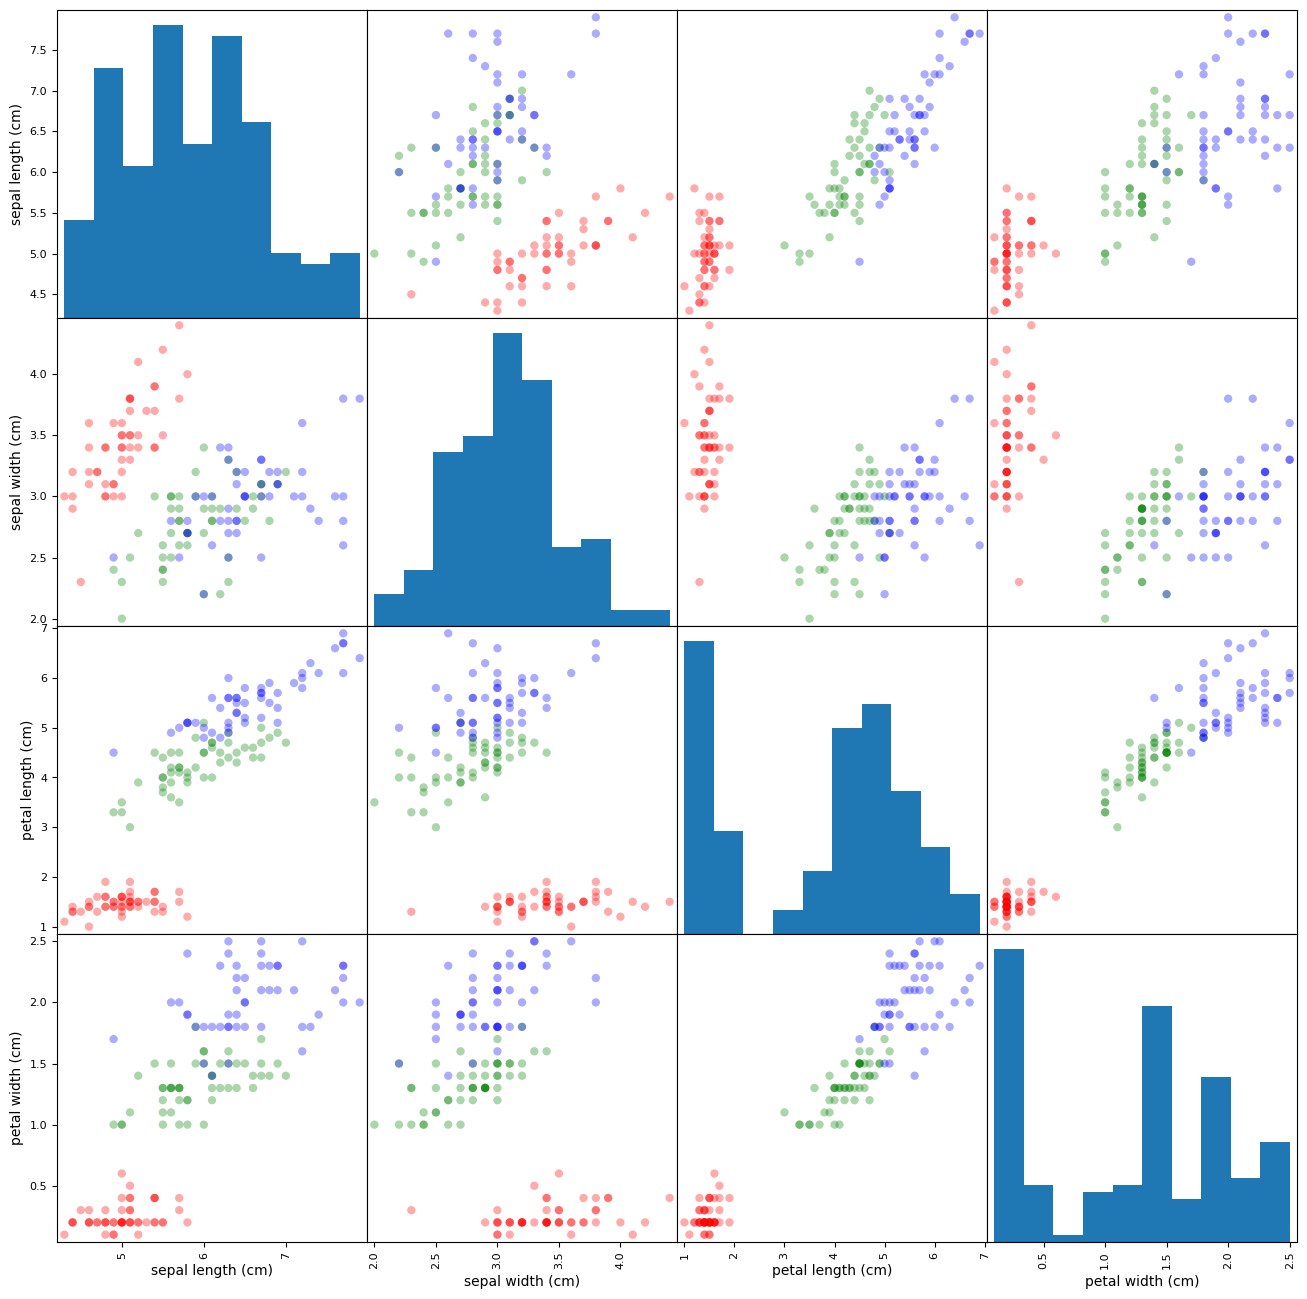

In [2]:
# 散布図行列
from pandas.plotting import scatter_matrix
sm = scatter_matrix(df_iris, 
    c = df_iris['species'].replace(
        {'setosa':'red', 'versicolor':'green', 'virginica':'blue'}
    ), 
    marker = 'o',
    alpha = 0.33,
    figsize = (16, 16)
)


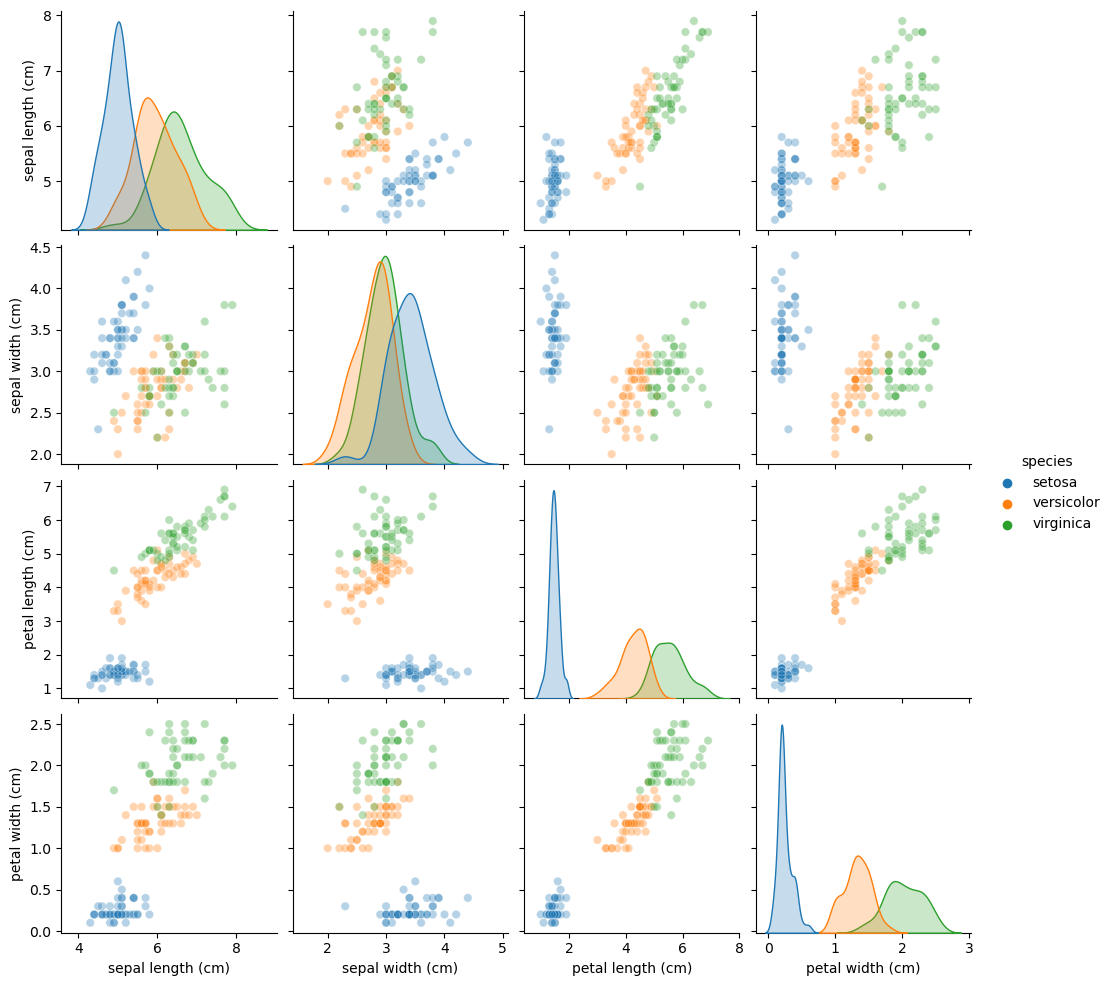

In [3]:
# 散布図行列
import seaborn as sns
pp = sns.pairplot(df_iris, 
    hue = "species", 
    plot_kws={'alpha': 0.33}
)

In [4]:
# クラスタリング

# K-means 法
from sklearn.cluster import KMeans
kmeans_iris = KMeans(3, random_state=0).fit(iris.data)

# Ward法
from sklearn.cluster import AgglomerativeClustering
ward_iris = AgglomerativeClustering(3).fit(iris.data)

# 混合ガウスモデル
from sklearn.mixture import GaussianMixture
gmm_iris = GaussianMixture(3, random_state=0,).fit(iris.data)

# 列の追加
df_iris['kmeans'] = kmeans_iris.predict(iris.data)
df_iris['ward'] = ward_iris.labels_
df_iris['gmm'] = gmm_iris.predict(iris.data)

df_iris

c:\Users\miura\miniconda3\envs\P39+\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,kmeans,ward,gmm
0,5.1,3.5,1.4,0.2,setosa,1,1,0
1,4.9,3.0,1.4,0.2,setosa,1,1,0
2,4.7,3.2,1.3,0.2,setosa,1,1,0
3,4.6,3.1,1.5,0.2,setosa,1,1,0
4,5.0,3.6,1.4,0.2,setosa,1,1,0
...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,2,2,1
146,6.3,2.5,5.0,1.9,virginica,0,0,1
147,6.5,3.0,5.2,2.0,virginica,2,2,1
148,6.2,3.4,5.4,2.3,virginica,2,2,1


In [5]:
# クラスタ番号を名前に付け替え
df_iris.replace(
    {'kmeans': {1:iris.target_names[0], 0:iris.target_names[1], 2:iris.target_names[2]},
       'ward': {1:iris.target_names[0], 0:iris.target_names[1], 2:iris.target_names[2]},
        'gmm': {0:iris.target_names[0], 2:iris.target_names[1], 1:iris.target_names[2]}
    },
    inplace=True
)

# df_iris.replace({'ward': {0:1, 1:0}}, inplace=True)   # 0↔1
# df_iris.replace({'gmm': {1:2, 2:1}}, inplace=True)    # 1↔2

df_iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,kmeans,ward,gmm
0,5.1,3.5,1.4,0.2,setosa,setosa,setosa,setosa
1,4.9,3.0,1.4,0.2,setosa,setosa,setosa,setosa
2,4.7,3.2,1.3,0.2,setosa,setosa,setosa,setosa
3,4.6,3.1,1.5,0.2,setosa,setosa,setosa,setosa
4,5.0,3.6,1.4,0.2,setosa,setosa,setosa,setosa
...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,virginica,virginica,virginica
146,6.3,2.5,5.0,1.9,virginica,versicolor,versicolor,virginica
147,6.5,3.0,5.2,2.0,virginica,virginica,virginica,virginica
148,6.2,3.4,5.4,2.3,virginica,virginica,virginica,virginica


In [6]:
# 混同行列と正解率
from sklearn.metrics import confusion_matrix
print(confusion_matrix(df_iris["species"], df_iris["kmeans"]), end='\t')
print('kmeans 正解率:', round(100*len(df_iris[df_iris['species']==df_iris['kmeans']])/len(df_iris)), "%")
print(confusion_matrix(df_iris["species"], df_iris["ward"]), end='\t')
print('  ward 正解率:', round(100*len(df_iris[df_iris['species']==df_iris['ward']])/len(df_iris)), "%")
print(confusion_matrix(df_iris["species"], df_iris["gmm"]), end='\t')
print('   gmm 正解率:', round(100*len(df_iris[df_iris['species']==df_iris['gmm']])/len(df_iris)), "%")

[[50  0  0]
 [ 0 48  2]
 [ 0 14 36]]	kmeans 正解率: 89 %
[[50  0  0]
 [ 0 49  1]
 [ 0 15 35]]	  ward 正解率: 89 %
[[50  0  0]
 [ 0 45  5]
 [ 0  0 50]]	   gmm 正解率: 97 %
